# Performance comercial dos pedidos de varejo

Começando a análise. Este estudo descreve a performance dos pedidos por período, mercado, canal, dispositivo e categoria, com foco em faturamento, volume, devoluções, risco e avaliação. Os nomes das colunas foram traduzidos para português-BR; os indicadores de risco permanecem literais porque seu significado operacional ainda não foi confirmado.

## Como a fonte foi lida?
A primeira checagem confirma o formato, a dimensão, os tipos e a legibilidade dos rótulos antes dos cálculos.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
raiz = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.data').exists())
df = pd.read_csv(raiz / '.data' / 'sales_retail.csv')
df.shape, df.head(3)

((12000, 23),
           order_id  order_date      country device_type  traffic_source  \
 0  ORD-2024-001936  2024-01-03      Belgium      Mobile        Paid Ads   
 1  ORD-2025-006495  2025-11-26  Netherlands     Desktop           Email   
 2  ORD-2023-001721  2023-11-07  Netherlands      Mobile  Organic Search   
 
   payment_method product_category  customer_age_days  previous_orders  \
 0    Credit Card           Sports                381                3   
 1     Debit Card           Garden                561                6   
 2     Debit Card           Garden                324                2   
 
    avg_order_value_eur  order_value_eur  quantity  discount_rate  \
 0                28.66            33.71         2           0.12   
 1                41.93            73.29         3           0.03   
 2               102.67            55.49         1           0.05   
 
    shipping_distance_km  delivery_days_estimated  late_delivery_risk  \
 0                105.70       

## Qual identidade visual será usada?
A paleta Okabe–Ito mantém contraste e acessibilidade, enquanto os rótulos diretos deixam os valores visíveis no próprio gráfico.

## Quais são os perfis iniciais da base?
O resumo numérico e as frequências principais ajudam a confirmar escala, distribuição e categorias dominantes antes das comparações.

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age_days,"12,000.00",352.79,237.56,5.00,177.00,299.00,475.00,"1,832.00"
previous_orders,"12,000.00",1.94,1.90,0.00,1.00,1.00,3.00,13.00
avg_order_value_eur,"12,000.00",48.94,28.72,8.00,29.07,42.10,61.01,350.45
order_value_eur,"12,000.00",61.05,55.54,5.00,26.62,45.34,75.95,810.75
quantity,"12,000.00",2.17,1.63,1.00,1.00,2.00,3.00,8.00
discount_rate,"12,000.00",0.15,0.11,0.00,0.06,0.12,0.21,0.75
shipping_distance_km,"12,000.00",479.20,330.31,5.00,236.10,404.45,645.23,"2,589.70"
delivery_days_estimated,"12,000.00",4.06,1.11,1.00,3.00,4.00,5.00,9.00
late_delivery_risk,"12,000.00",0.06,0.24,0.00,0.00,0.00,0.00,1.00
address_mismatch,"12,000.00",0.05,0.22,0.00,0.00,0.00,0.00,1.00


In [3]:
df['product_category'].value_counts().to_frame('pedidos')

,pedidos
product_category,
Home & Kitchen,2468
Electronics,2008
Fashion,1702
Garden,1436
Sports,1291
Beauty,1106
Toys,1099
Pet Supplies,890


In [4]:
COR_PRIMARIA = '#0072B2'
COR_SECUNDARIA = '#94A3B8'
COR_DESTAQUE = '#E69F00'
COR_EIXO = '#B0B7C3'
COR_TEXTO = '#334155'
PALETA = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00']
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 110, 'font.size': 11, 'text.color': COR_TEXTO, 'axes.titlesize': 15, 'axes.titleweight': 'bold', 'axes.titlecolor': COR_TEXTO, 'axes.labelcolor': COR_EIXO, 'axes.edgecolor': COR_EIXO, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False, 'xtick.color': COR_EIXO, 'ytick.color': COR_EIXO})

## Os nomes das colunas deixam o conteúdo claro?
A tradução facilita a leitura comercial e mantém os campos de risco como indicadores, sem inventar uma definição que não veio com a fonte.

In [5]:
nomes_pt = {'order_id':'id_pedido','order_date':'data_pedido','country':'pais','device_type':'tipo_dispositivo','traffic_source':'origem_trafego','payment_method':'metodo_pagamento','product_category':'categoria_produto','customer_age_days':'dias_desde_cadastro_cliente','previous_orders':'pedidos_anteriores','avg_order_value_eur':'valor_medio_pedido_eur','order_value_eur':'valor_pedido_eur','quantity':'quantidade','discount_rate':'taxa_desconto','shipping_distance_km':'distancia_entrega_km','delivery_days_estimated':'dias_entrega_estimados','late_delivery_risk':'indicador_risco_atraso','address_mismatch':'indicador_divergencia_endereco','high_risk_ip':'indicador_ip_alto_risco','customer_support_contacts':'contatos_suporte','review_score':'nota_avaliacao','is_returned':'indicador_devolucao','is_fraud':'indicador_fraude','risk_label':'classificacao_risco'}
df = df.rename(columns=nomes_pt)
df[['id_pedido','data_pedido','pais','valor_pedido_eur','classificacao_risco']].head()

,id_pedido,data_pedido,pais,valor_pedido_eur,classificacao_risco
0,ORD-2024-001936,2024-01-03,Belgium,33.71,Normal
1,ORD-2025-006495,2025-11-26,Netherlands,73.29,Normal
2,ORD-2023-001721,2023-11-07,Netherlands,55.49,Normal
3,ORD-2024-009121,2024-05-28,Netherlands,112.54,Return Risk
4,ORD-2025-000361,2025-01-31,Netherlands,55.32,Normal


## A fonte tem qualidade suficiente para uma leitura de performance?
Vamos verificar cobertura, duplicidade e coerência básica dos identificadores e indicadores.

In [6]:
qualidade = pd.DataFrame({'linhas':[len(df)], 'colunas':[df.shape[1]], 'nulos':[int(df.isna().sum().sum())], 'ids_duplicados':[int(df['id_pedido'].duplicated().sum())], 'data_inicial':[df['data_pedido'].min()], 'data_final':[df['data_pedido'].max()]})
qualidade

,linhas,colunas,nulos,ids_duplicados,data_inicial,data_final
0,12000,23,0,0,2023-01-01,2025-12-31


In [7]:
df['data_pedido'] = pd.to_datetime(df['data_pedido'])
df['mes_periodo'] = df['data_pedido'].dt.to_period('M')
df['mes'] = df['mes_periodo'].dt.strftime('%m/%y')
df[['data_pedido','mes_periodo','mes']].head()

,data_pedido,mes_periodo,mes
0,2024-01-03,2024-01,01/24
1,2025-11-26,2025-11,11/25
2,2023-11-07,2023-11,11/23
3,2024-05-28,2024-05,05/24
4,2025-01-31,2025-01,01/25


**Leitura crítica:** a base permite comparar períodos e segmentos porque não apresenta nulos nem IDs repetidos. Isso não comprova que os indicadores de risco estejam conceitualmente corretos; eles ainda precisam de documentação operacional.

## Como o volume e o faturamento evoluíram ao longo do tempo?
A visão mensal mostra a escala de pedidos e o valor comercial movimentado, sem confundir crescimento de volume com crescimento de valor.

In [8]:
mensal = df.groupby('mes_periodo').agg(pedidos=('id_pedido','count'), faturamento_eur=('valor_pedido_eur','sum'), ticket_medio_eur=('valor_pedido_eur','mean')).reset_index()
mensal['mes'] = mensal['mes_periodo'].dt.strftime('%m/%y')
mensal = mensal[['mes','pedidos','faturamento_eur','ticket_medio_eur']]
mensal.tail(12)

,mes,pedidos,faturamento_eur,ticket_medio_eur
24,01/25,328,"21,005.01",64.04
25,02/25,298,"18,359.09",61.61
26,03/25,351,"21,085.57",60.07
27,04/25,377,"23,166.32",61.45
28,05/25,351,"21,800.75",62.11
29,06/25,338,"20,675.75",61.17
30,07/25,373,"21,044.76",56.42
31,08/25,336,"19,538.66",58.15
32,09/25,348,"22,026.23",63.29
33,10/25,322,"19,543.90",60.70


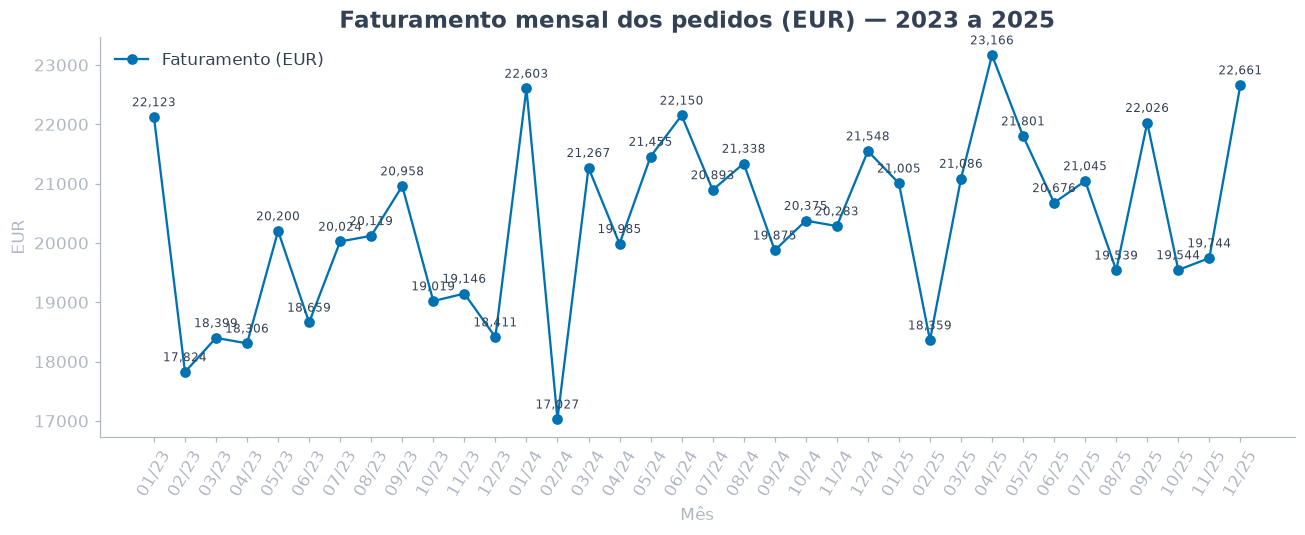

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mensal['mes'], mensal['faturamento_eur'], marker='o', color=COR_PRIMARIA, label='Faturamento (EUR)')
for x, y in zip(mensal['mes'], mensal['faturamento_eur']): ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
ax.set_title('Faturamento mensal dos pedidos (EUR) — 2023 a 2025'); ax.set_xlabel('Mês'); ax.set_ylabel('EUR'); ax.tick_params(axis='x', rotation=60); ax.legend(frameon=False); plt.tight_layout()

## Quais categorias concentram valor e volume?
O ranking combina quantidade de pedidos e faturamento para separar categorias grandes de categorias com maior valor médio.

In [10]:
categorias = df.groupby('categoria_produto').agg(pedidos=('id_pedido','count'), faturamento_eur=('valor_pedido_eur','sum'), ticket_medio_eur=('valor_pedido_eur','mean'), devolucoes=('indicador_devolucao','sum')).sort_values('faturamento_eur', ascending=False).reset_index()
categorias.style.format({'faturamento_eur':'€ {:,.2f}', 'ticket_medio_eur':'€ {:,.2f}'})

,categoria_produto,pedidos,faturamento_eur,ticket_medio_eur,devolucoes
0,Electronics,2008,"€ 204,420.90",€ 101.80,230
1,Home & Kitchen,2468,"€ 165,681.37",€ 67.13,208
2,Garden,1436,"€ 85,239.27",€ 59.36,90
3,Fashion,1702,"€ 83,138.24",€ 48.85,276
4,Sports,1291,"€ 72,095.86",€ 55.84,107
5,Toys,1099,"€ 47,679.04",€ 43.38,72
6,Beauty,1106,"€ 39,775.53",€ 35.96,79
7,Pet Supplies,890,"€ 34,609.86",€ 38.89,50


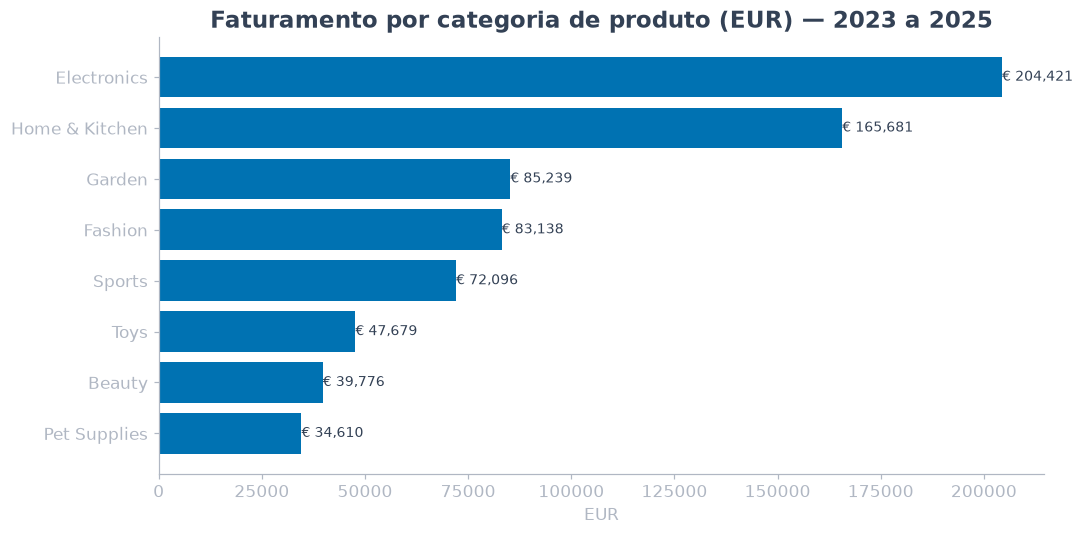

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
base = categorias.sort_values('faturamento_eur')
barras = ax.barh(base['categoria_produto'], base['faturamento_eur'], color=COR_PRIMARIA)
for barra in barras: ax.text(barra.get_width(), barra.get_y()+barra.get_height()/2, f'€ {barra.get_width():,.0f}', va='center', ha='left', fontsize=9)
ax.set_title('Faturamento por categoria de produto (EUR) — 2023 a 2025'); ax.set_xlabel('EUR'); ax.set_ylabel(''); plt.tight_layout()

## Quais canais e dispositivos apresentam melhor desempenho?
Comparamos faturamento, ticket e taxa de devolução. A taxa, e não apenas o número absoluto, evita penalizar segmentos maiores.

In [12]:
por_canal = df.groupby('origem_trafego').agg(pedidos=('id_pedido','count'), faturamento_eur=('valor_pedido_eur','sum'), ticket_medio_eur=('valor_pedido_eur','mean'), taxa_devolucao=('indicador_devolucao','mean'), nota_media=('nota_avaliacao','mean')).sort_values('faturamento_eur', ascending=False).reset_index()
por_canal['taxa_devolucao'] = por_canal['taxa_devolucao'] * 100
por_canal.style.format({'faturamento_eur':'€ {:,.2f}', 'ticket_medio_eur':'€ {:,.2f}', 'taxa_devolucao':'{:.1f}%', 'nota_media':'{:.2f}'})

,origem_trafego,pedidos,faturamento_eur,ticket_medio_eur,taxa_devolucao,nota_media
0,Organic Search,2950,"€ 183,265.82",€ 62.12,9.6%,4.41
1,Paid Ads,2648,"€ 160,452.74",€ 60.59,8.6%,4.43
2,Social Media,2209,"€ 130,456.33",€ 59.06,9.2%,4.42
3,Direct,1764,"€ 110,876.23",€ 62.86,9.2%,4.42
4,Marketplace,1530,"€ 92,390.19",€ 60.39,9.4%,4.39
5,Email,899,"€ 55,198.76",€ 61.40,10.0%,4.39


In [13]:
por_dispositivo = df.groupby('tipo_dispositivo').agg(pedidos=('id_pedido','count'), faturamento_eur=('valor_pedido_eur','sum'), ticket_medio_eur=('valor_pedido_eur','mean'), taxa_devolucao=('indicador_devolucao','mean')).reset_index()
por_dispositivo['taxa_devolucao'] = por_dispositivo['taxa_devolucao'] * 100
por_dispositivo.style.format({'faturamento_eur':'€ {:,.2f}', 'ticket_medio_eur':'€ {:,.2f}', 'taxa_devolucao':'{:.1f}%'})

,tipo_dispositivo,pedidos,faturamento_eur,ticket_medio_eur,taxa_devolucao
0,Desktop,3813,"€ 232,288.97",€ 60.92,9.2%
1,Mobile,7354,"€ 450,529.91",€ 61.26,9.3%
2,Tablet,833,"€ 49,821.19",€ 59.81,9.7%


## Onde estão as maiores taxas de devolução e risco?
A comparação por país usa taxas com o número de pedidos ao lado. Assim, concentração de casos não é confundida com maior risco proporcional.

In [14]:
por_pais = df.groupby('pais').agg(pedidos=('id_pedido','count'), faturamento_eur=('valor_pedido_eur','sum'), taxa_devolucao=('indicador_devolucao','mean'), taxa_fraude=('indicador_fraude','mean'), nota_media=('nota_avaliacao','mean')).reset_index()
por_pais['taxa_devolucao'] = por_pais['taxa_devolucao'] * 100; por_pais['taxa_fraude'] = por_pais['taxa_fraude'] * 100
por_pais.sort_values('taxa_devolucao', ascending=False).style.format({'faturamento_eur':'€ {:,.2f}', 'taxa_devolucao':'{:.1f}%', 'taxa_fraude':'{:.1f}%', 'nota_media':'{:.2f}'})

,pais,pedidos,faturamento_eur,taxa_devolucao,taxa_fraude,nota_media
3,Italy,915,"€ 54,606.58",10.2%,4.7%,4.39
0,Belgium,1970,"€ 121,109.67",10.1%,3.3%,4.40
7,Turkey,840,"€ 52,728.71",9.8%,3.3%,4.39
5,Poland,862,"€ 51,458.58",9.7%,3.8%,4.44
2,Germany,1650,"€ 102,807.73",9.3%,3.5%,4.40
4,Netherlands,3388,"€ 205,837.73",8.9%,3.7%,4.42
1,France,1305,"€ 80,181.16",8.7%,4.3%,4.44
6,Spain,1070,"€ 63,909.91",7.9%,3.6%,4.41


In [15]:
risco = df.groupby('classificacao_risco').agg(pedidos=('id_pedido','count'), faturamento_eur=('valor_pedido_eur','sum'), taxa_devolucao=('indicador_devolucao','mean'), nota_media=('nota_avaliacao','mean')).reset_index().sort_values('pedidos', ascending=False)
risco['taxa_devolucao'] = risco['taxa_devolucao'] * 100
risco.style.format({'faturamento_eur':'€ {:,.2f}', 'taxa_devolucao':'{:.1f}%', 'nota_media':'{:.2f}'})

,classificacao_risco,pedidos,faturamento_eur,taxa_devolucao,nota_media
1,Normal,10482,"€ 637,909.27",0.0%,4.51
2,Return Risk,1071,"€ 67,749.32",100.0%,3.41
0,Fraud Risk,447,"€ 26,981.48",9.2%,4.41


## Síntese para a equipe comercial e de dados
**Achados:** foram analisados `12.000` pedidos, que movimentam `€ 732.640,07`, com ticket médio de `€ 61,05`. A categoria Electronics lidera o faturamento, com `€ 204.420,90`, e também tem o maior ticket médio, de aproximadamente `€ 101,80`. A origem Organic Search lidera o faturamento entre os canais, com `€ 183.265,82`; Paid Ads tem a maior taxa de fraude observada entre os canais, `6,0%`, em `2.648` pedidos.

A categoria Fashion merece atenção comercial porque apresenta a maior taxa de devolução, `16,2%`, em `1.702` pedidos. Na dimensão geográfica, a Itália tem a maior taxa de fraude, `4,7%`, mas com `915` pedidos; isso é uma taxa proporcional, não o maior volume absoluto de casos. O dispositivo Mobile concentra o maior faturamento por também concentrar a maior quantidade de pedidos, enquanto o ticket médio é semelhante entre dispositivos.

**Limitações:** os dados não documentam a origem, a regra de classificação de risco nem se `valor_pedido_eur` representa receita bruta, líquida ou já descontada. `dias_desde_cadastro_cliente` também precisa de confirmação semântica. As comparações são descritivas e indicam associação, não causalidade.

**Próximas decisões:** validar o dicionário de dados com a área responsável; confirmar a definição de receita e dos indicadores de risco; depois, acompanhar mensalmente faturamento, ticket, devolução e fraude por canal, país e categoria.